# Phần A — CNN Baseline và Feature Map Shapes
**Weather Recognition · Một cấu hình · Một split · Một mốc so sánh**

Mục tiêu: phân loại ảnh thời tiết bằng CNN huấn luyện từ đầu và theo dõi kích thước feature map.

**Mạch trình bày:** dữ liệu → kiểm tra → train/dev → input → CNN → shapes → học → đánh giá.

Nguồn: [Multi-Class Images for Weather Classification](https://www.kaggle.com/datasets/somesh24/multiclass-images-for-weather-classification/data). Dữ liệu được lấy bằng **Kaggle REST API vào runtime Colab**, không cần tải về máy rồi upload.

## 1. Thiết lập thí nghiệm
Cố định seed **42**; chỉ dùng ảnh RGB **128×128**. Mọi bước sau dùng lại các cấu hình này.

In [1]:
#@title 1.1 Thư viện và cấu hình
import io, zipfile, requests, re, hashlib, random, os, json
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from IPython.display import display, Markdown

SEED = 42
IMG_SIZE = (128, 128)
DATASET = "somesh24/multiclass-images-for-weather-classification"

## 2. Nhập dữ liệu bằng Kaggle API
API của dataset công khai được gọi trực tiếp. Nếu đã có dữ liệu trong runtime, bỏ qua lần tải tiếp theo. Không cần lưu API key khi truy cập công khai thành công.

In [2]:
#@title 2.1 Nạp dataset vào runtime
ROOT = Path("/content/weather_data")
ROOT.mkdir(exist_ok=True)
# Public dataset: thử API không cần token; không ghi khóa vào notebook.
if not any(ROOT.rglob("*.jpg")):
    response = requests.get(f"https://www.kaggle.com/api/v1/datasets/download/{DATASET}", timeout=180)
    response.raise_for_status()
    if not zipfile.is_zipfile(io.BytesIO(response.content)):
        raise RuntimeError("Kaggle API không trả ZIP. Cần kiểm tra quyền truy cập/API token.")
    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        archive.extractall(ROOT)
    del response
print("Dữ liệu Kaggle API:", ROOT)

Dữ liệu Kaggle API: /content/weather_data


## 3. Kiểm tra chất lượng dữ liệu
Nhãn lấy từ tiền tố tên ảnh. Đọc từng ảnh dưới dạng RGB; kiểm tra lỗi và tính SHA-256 trên pixel để phát hiện bản trùng chính xác.

In [3]:
#@title 3.1 Kiểm tra ảnh và lập danh mục
rows, bad = [], []
for p in sorted(ROOT.rglob("*")):
    if p.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
        continue
    match = re.match(r"([a-zA-Z]+)", p.stem)
    if not match:
        raise ValueError(f"Không xác định được nhãn: {p.name}")
    try:
        with Image.open(p) as im:
            rgb = ImageOps.exif_transpose(im).convert("RGB")
            digest = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
        rows.append({"path": str(p), "class": match.group(1).lower(), "sha256": digest})
    except (OSError, ValueError) as e:
        bad.append((p.name, str(e)))

In [4]:
#@title 3.2 Loại bản trùng trước khi chia tập
df = pd.DataFrame(rows)
assert len(df), "Không tìm thấy ảnh"
assert df.groupby("sha256")["class"].nunique().max() == 1, "Ảnh trùng có nhãn mâu thuẫn"
n_duplicate = int(df.duplicated("sha256").sum())
df = df.drop_duplicates("sha256").reset_index(drop=True)
classes = sorted(df["class"].unique())
assert len(classes) == 4, classes
df["label"] = df["class"].map({c: i for i, c in enumerate(classes)})
print(f"Ảnh đọc được: {len(rows)} | Hỏng: {len(bad)} | Bản trùng: {n_duplicate} | Còn lại: {len(df)}")
if bad: print(bad)
display(df.groupby("class").size().rename("Số ảnh").to_frame())

Ảnh đọc được: 1125 | Hỏng: 0 | Bản trùng: 26 | Còn lại: 1099


,Số ảnh
class,
cloudy,291
rain,206
shine,250
sunrise,352


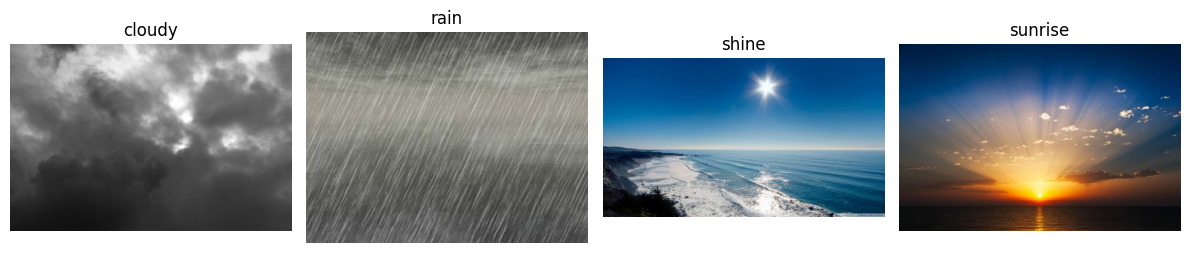

In [5]:
#@title 3.3 Xem một ảnh đại diện mỗi lớp
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(classes), figsize=(12,3))
for ax, label in zip(axes, classes):
    p = df.loc[df["class"] == label, "path"].iloc[0]
    with Image.open(p) as im:
        ax.imshow(ImageOps.exif_transpose(im).convert("RGB"))
    ax.set_title(label); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Chia train/dev theo lớp
**80% train / 20% dev, stratify theo class.** Tỷ lệ lớp được giữ gần như nguyên vẹn. Loại ảnh trùng trước split giúp tránh rò rỉ ảnh giống hệt giữa hai tập.

In [6]:
#@title 4.1 Tạo split có thể tái lập
from sklearn.model_selection import train_test_split
train_df, dev_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
train_df, dev_df = train_df.reset_index(drop=True), dev_df.reset_index(drop=True)
assert set(train_df.sha256).isdisjoint(dev_df.sha256)
print("Train:", len(train_df), "| Dev:", len(dev_df))

Train: 879 | Dev: 220


In [7]:
#@title 4.2 Kiểm tra phân bố lớp sau split
counts = pd.DataFrame({"total": df["class"].value_counts(), "train": train_df["class"].value_counts(), "dev": dev_df["class"].value_counts()}).reindex(classes)
display(counts)
train_df.to_csv("/content/train_split.csv", index=False)
dev_df.to_csv("/content/dev_split.csv", index=False)

,total,train,dev
class,,,
cloudy,291,233,58
rain,206,165,41
shine,250,200,50
sunrise,352,281,71


## 5. Chọn input và tiền xử lý
**RGB 128×128** giữ màu sắc, mây và bố cục cảnh đủ cho baseline, với chi phí tính toán thấp trên dataset nhỏ. Chỉ chọn một độ phân giải.

Resize bilinear → float32 → chia 255. Không augmentation trong baseline; train và dev dùng cùng cách tiền xử lý.

In [8]:
#@title 5.1 Cấu hình TensorFlow
import tensorflow as tf
import sklearn, platform
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
print("Python:", platform.python_version(), "TensorFlow:", tf.__version__, "sklearn:", sklearn.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Python: 3.13.15 TensorFlow: 2.20.0 sklearn: 1.6.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
#@title 5.2 Đọc ảnh RGB và chuẩn hóa [0,1]
def load_images(frame):
    images = []
    for p in frame.path:
        with Image.open(p) as im:
            im = ImageOps.exif_transpose(im).convert("RGB").resize(IMG_SIZE, Image.Resampling.BILINEAR)
            images.append(np.asarray(im, dtype=np.float32) / 255.0)
    return np.stack(images), frame.label.to_numpy(dtype=np.int32)
X_train, y_train = load_images(train_df)
X_dev, y_dev = load_images(dev_df)
print("X_train:", X_train.shape, "X_dev:", X_dev.shape)

X_train: (879, 128, 128, 3) X_dev: (220, 128, 128, 3)


In [10]:
#@title 5.3 Tạo batch — chỉ shuffle train
BATCH_SIZE = 32
# Chỉ shuffle train. Giữ nguyên thứ tự dev để nhãn khớp dự đoán.
options = tf.data.Options()
options.threading.private_threadpool_size = 2
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(y_train), seed=SEED).batch(BATCH_SIZE).with_options(options).prefetch(1)
dev_ds = tf.data.Dataset.from_tensor_slices((X_dev, y_dev)).batch(BATCH_SIZE).with_options(options).prefetch(1)
train_eval_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).with_options(options).prefetch(1)

## 6. Xây CNN baseline
Ba block **Conv2D 3×3 + ReLU → MaxPool 2×2**, lần lượt 32, 64, 128 filters.

Global Average Pooling giảm số tham số so với Flatten; Dense 64 và Dropout 0.3 trước Softmax 4 lớp. Model học từ đầu.

In [11]:
#@title 6.1 Khai báo kiến trúc
model = keras.Sequential([
    keras.Input(shape=(128,128,3)),
    layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1"),
    layers.MaxPooling2D(2, name="pool1"),
    layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2"),
    layers.MaxPooling2D(2, name="pool2"),
    layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3"),
    layers.MaxPooling2D(2, name="pool3"),
    layers.GlobalAveragePooling2D(name="global_avg_pool"),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation="softmax", name="class_probabilities")
], name="weather_cnn_baseline")

In [12]:
#@title 6.2 Xem số tham số
model.summary()

Model: "weather_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Feature map sau từng Conv và Pool
Quy ước **(B,H,W,C)**; B là batch size động. Conv stride 1, padding same giữ H,W; Pool 2×2 stride 2 giảm mỗi chiều một nửa. Bảng dưới lấy trực tiếp từ model.

In [13]:
#@title 7.1 Bảng feature map shapes
shape_table = pd.DataFrame([{"Layer": layer.name, "Type": type(layer).__name__, "Output (B,H,W,C)": str(tuple(layer.output.shape))} for layer in model.layers if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D))])
display(shape_table)

,Layer,Type,"Output (B,H,W,C)"
0,conv1,Conv2D,"(None, 128, 128, 32)"
1,pool1,MaxPooling2D,"(None, 64, 64, 32)"
2,conv2,Conv2D,"(None, 64, 64, 64)"
3,pool2,MaxPooling2D,"(None, 32, 32, 64)"
4,conv3,Conv2D,"(None, 32, 32, 128)"
5,pool3,MaxPooling2D,"(None, 16, 16, 128)"


## 8. Huấn luyện một baseline
Adam, learning rate **0.001**, batch **32**, tối đa **20 epochs**. Early stopping theo **dev loss**, patience 5; khôi phục checkpoint có dev loss thấp nhất. Không thử nhiều kiến trúc hay độ phân giải.

In [14]:
#@title 8.1 Loss, optimizer và tiêu chí dừng
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
EPOCHS = 20
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

In [15]:
#@title 8.2 Huấn luyện
history = model.fit(train_ds, validation_data=dev_ds, epochs=EPOCHS, callbacks=[early_stop], verbose=2)
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print("Checkpoint được chọn: epoch", best_epoch)

Epoch 1/20
28/28 - 6s - 205ms/step - accuracy: 0.5245 - loss: 1.1115 - val_accuracy: 0.5955 - val_loss: 0.7728
Epoch 2/20
28/28 - 1s - 25ms/step - accuracy: 0.6496 - loss: 0.7796 - val_accuracy: 0.6864 - val_loss: 0.6690
Epoch 3/20
28/28 - 1s - 25ms/step - accuracy: 0.7213 - loss: 0.6768 - val_accuracy: 0.6318 - val_loss: 0.6836
Epoch 4/20
28/28 - 1s - 41ms/step - accuracy: 0.7110 - loss: 0.6731 - val_accuracy: 0.7500 - val_loss: 0.5414
Epoch 5/20
28/28 - 1s - 21ms/step - accuracy: 0.7327 - loss: 0.5968 - val_accuracy: 0.8136 - val_loss: 0.4973
Epoch 6/20
28/28 - 1s - 26ms/step - accuracy: 0.7600 - loss: 0.5681 - val_accuracy: 0.8091 - val_loss: 0.4954
Epoch 7/20
28/28 - 1s - 26ms/step - accuracy: 0.7600 - loss: 0.5740 - val_accuracy: 0.8091 - val_loss: 0.4812
Epoch 8/20
28/28 - 1s - 24ms/step - accuracy: 0.7861 - loss: 0.5319 - val_accuracy: 0.7864 - val_loss: 0.4950
Epoch 9/20
28/28 - 1s - 23ms/step - accuracy: 0.7884 - loss: 0.5147 - val_accuracy: 0.8591 - val_loss: 0.4389
Epoch 10/

## 9. Đọc đường học
Quan sát loss và accuracy của train/dev theo epoch. Đường dọc đánh dấu checkpoint được dùng cho toàn bộ báo cáo cuối.

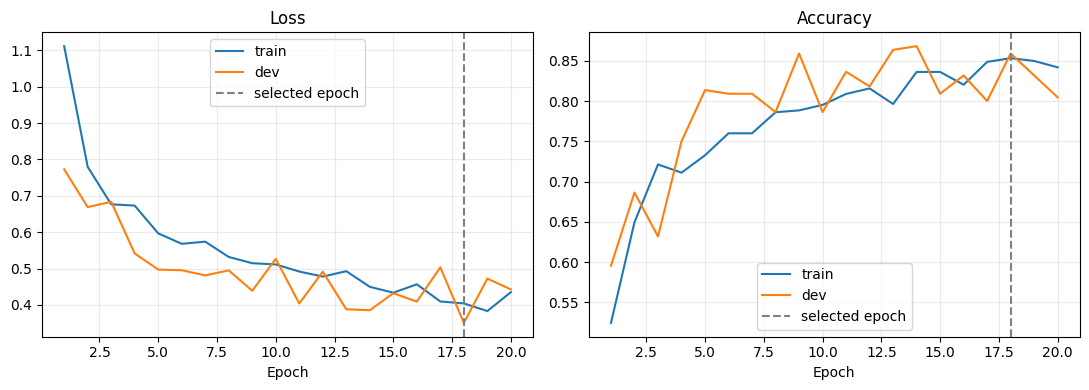

In [16]:
#@title 9.1 Learning curves
fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax, key, title in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    ax.plot(np.arange(1,len(history.history[key])+1), history.history[key], label="train")
    ax.plot(np.arange(1,len(history.history[key])+1), history.history["val_"+key], label="dev")
    ax.axvline(best_epoch, color="gray", linestyle="--", label="selected epoch")
    ax.set(xlabel="Epoch", title=title); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 10. Đánh giá cùng một checkpoint
Dự đoán lại train và dev ở chế độ inference (Dropout tắt). **Train accuracy** dưới đây không phải accuracy trung bình trong lúc cập nhật trọng số.

**Macro-F1** cho mỗi lớp trọng số bằng nhau, bổ sung góc nhìn khi số ảnh các lớp khác nhau.

In [17]:
#@title 10.1 Dự đoán train và dev
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
train_pred = model.predict(train_eval_ds, verbose=0).argmax(axis=1)
dev_pred = model.predict(dev_ds, verbose=0).argmax(axis=1)

In [18]:
#@title 10.2 Báo cáo accuracy và macro-F1
metrics = {
    "train_accuracy": float(accuracy_score(y_train, train_pred)),
    "dev_accuracy": float(accuracy_score(y_dev, dev_pred)),
    "dev_macro_f1": float(f1_score(y_dev, dev_pred, labels=range(len(classes)), average="macro", zero_division=0)),
    "best_epoch_by_dev_loss": best_epoch,
    "epochs_run": len(history.history["loss"])
}
display(pd.DataFrame([metrics]).round(4))

,train_accuracy,dev_accuracy,dev_macro_f1,best_epoch_by_dev_loss,epochs_run
0,0.8555,0.8591,0.844,18,20


In [19]:
#@title 10.3 Precision / Recall / F1 từng lớp
print(classification_report(y_dev, dev_pred, labels=range(len(classes)), target_names=classes, digits=4, zero_division=0))

              precision    recall  f1-score   support

      cloudy     0.8298    0.6724    0.7429        58
        rain     0.6735    0.8049    0.7333        41
       shine     0.8727    0.9600    0.9143        50
     sunrise     1.0000    0.9718    0.9857        71

    accuracy                         0.8591       220
   macro avg     0.8440    0.8523    0.8440       220
weighted avg     0.8653    0.8591    0.8584       220



## 11. Confusion matrix
**Hàng là nhãn thật, cột là dự đoán.** Đường chéo là dự đoán đúng; các ô ngoài đường chéo cho biết cặp lớp bị nhầm.

CONFUSION MATRIX — hàng: nhãn thật; cột: dự đoán; thứ tự: ['cloudy', 'rain', 'shine', 'sunrise']


,cloudy,rain,shine,sunrise
cloudy,39,15,4,0
rain,6,33,2,0
shine,1,1,48,0
sunrise,1,0,1,69


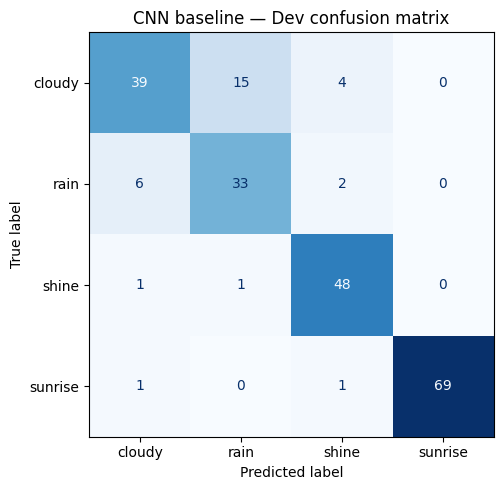

In [20]:
#@title 11.1 Ma trận nhầm lẫn trên dev
cm = confusion_matrix(y_dev, dev_pred, labels=range(len(classes)))
print("CONFUSION MATRIX — hàng: nhãn thật; cột: dự đoán; thứ tự:", classes)
display(pd.DataFrame(cm, index=classes, columns=classes))
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("CNN baseline — Dev confusion matrix")
plt.tight_layout(); plt.savefig("/content/confusion_matrix.png", dpi=150); plt.show()

## 12. Kết luận và giới hạn
Kết quả dưới đây là mốc baseline của **một seed, một split**. Dev được dùng chọn checkpoint nên chưa phải đánh giá trên test độc lập. Kiểm tra trùng chỉ loại ảnh RGB giống hệt, chưa loại ảnh gần trùng.

In [21]:
#@title 12.1 Tóm tắt kết quả thực nghiệm
gap = metrics["train_accuracy"] - metrics["dev_accuracy"]
display(Markdown(f"**Train accuracy:** {metrics['train_accuracy']:.2%} · **Dev accuracy:** {metrics['dev_accuracy']:.2%} · **Dev macro-F1:** {metrics['dev_macro_f1']:.4f}  \n**Checkpoint:** epoch {best_epoch} · **Train−dev gap:** {gap:.2%}"))

**Train accuracy:** 85.55% · **Dev accuracy:** 85.91% · **Dev macro-F1:** 0.8440  
**Checkpoint:** epoch 18 · **Train−dev gap:** -0.36%

### Nhận xét cho lần chạy đã báo cáo
- CNN 3 block đạt **85,55% train accuracy**, **85,91% dev accuracy**, **macro-F1 0,8440**; dùng checkpoint **epoch 18** trong 20 epochs.
- Dev cao hơn train khoảng **0,36 điểm phần trăm**. Chênh lệch nhỏ ở split này; chưa đủ để khẳng định khả năng tổng quát hóa trên dữ liệu khác.
- Nhầm nhiều nhất: **15 ảnh cloudy → rain**, chiều ngược lại **6 ảnh rain → cloudy**. Đây là cặp lớp cần ưu tiên phân tích ở bước tiếp theo.
- Nhận diện đúng **48/50 ảnh shine** và **69/71 ảnh sunrise**. Macro-F1 thấp hơn accuracy cho thấy chất lượng chưa đồng đều giữa các lớp.

*Các con số trên thuộc lần chạy seed 42 trên GPU T4; khi chạy lại, đọc bảng tính tự động ở trên. Bài này dừng ở Phần A.*

In [22]:
#@title 12.2 Lưu artifacts trong runtime
model.save("/content/weather_cnn_baseline.keras")
Path("/content/baseline_metrics.json").write_text(json.dumps({**metrics, "classes": classes, "confusion_matrix": cm.tolist(), "seed": SEED, "input_size": IMG_SIZE}, ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame(history.history).to_csv("/content/training_history.csv", index=False)
print("Đã lưu model, metrics, split CSV và confusion matrix trong /content của runtime.")

Đã lưu model, metrics, split CSV và confusion matrix trong /content của runtime.
